# Temat: Predykcja popytu na produkty

### Stakeholderzy: Dział sprzedaży, marketing, zarządzanie łańcuchem dostaw, klienci.
### Opis: Modelowanie popytu na produkty w różnych okresach, aby zoptymalizować zapasy i produkcję.

### Dataset: https://www.kaggle.com/c/rossmann-store-sales

### Authors:
- Joanna Sawicka
- Kiryl Radkevich
- Robert Walkiewicz
- Marek Lipiński

In [1]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.svm import LinearSVR

d:\Anaconda\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


train = pd.read_csv('..//data/train.csv')
store = pd.read_csv('..//data/store.csv')

print(train.shape)
print(store.shape)

C:\Users\marek.lipinski\AppData\Local\Temp\ipykernel_29548\526895874.py:7: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv('..//data/train.csv')


(1017209, 9)
(1115, 10)


In [3]:
train.head()


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [4]:
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [5]:
store.info()

<class 'pandas.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   str    
 2   Assortment                 1115 non-null   str    
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    str    
dtypes: float64(5), int64(2), str(3)
memory usage: 98.0 KB


In [6]:
train.isnull().sum()

Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

In [7]:
store.isnull().sum()

Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64

In [8]:
df = pd.merge(train, store, on='Store', how='left')
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [9]:
df.isna().sum()

Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2                            0
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
dtype: int64

## Imputation of missing data

In [10]:
#Based on kaggle: 
# CompetitionDistance - distance in meters to the nearest competitor store

In [11]:
max_distance = df['CompetitionDistance'].max()   
max_distance 

75860.0

In [12]:
df['CompetitionDistance'] = df['CompetitionDistance'].fillna(max_distance) # If null in row - store have no competitors in neighbourhood. Fill with max. value is the most reasonable choice.

In [13]:
# CompetitionOpenSince[Month/Year] - gives the approximate year and month of the time the nearest competitor was opened
df['CompetitionOpenSinceMonth']

0           9.0
1          11.0
2          12.0
3           9.0
4           4.0
           ... 
1017204     6.0
1017205     4.0
1017206     NaN
1017207     NaN
1017208     NaN
Name: CompetitionOpenSinceMonth, Length: 1017209, dtype: float64

In [14]:
df['CompetitionOpenSinceYear'].max()

2015.0

In [15]:
df[df['CompetitionOpenSinceYear'] == 2015]['CompetitionOpenSinceMonth'].max()

8.0

In [16]:
# filling with month 12 (Dec) allows later to push the missing dates into the future (negative value in result). Important in feature eng. !!
df['CompetitionOpenSinceMonth'] = df['CompetitionOpenSinceMonth'].fillna(12)

In [17]:
df['CompetitionOpenSinceYear'] = df['CompetitionOpenSinceYear'].fillna(2015)
df.isna().sum()

Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance               0
CompetitionOpenSinceMonth         0
CompetitionOpenSinceYear          0
Promo2                            0
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
dtype: int64

In [18]:
#Based on kaggle: Promo2Since[Year/Week] - describes the year and calendar week when the store started participating in Promo2

In [19]:
df['Promo2SinceWeek'] = df['Promo2SinceWeek'].fillna(0) # 0 means there was no promo
df['Promo2SinceYear'] = df['Promo2SinceYear'].fillna(2015) # 2015 to get 0 when calculating promo period
df['PromoInterval'] = df['PromoInterval'].fillna("None") # "None" for stores without promo

In [20]:
df.isna().sum()

Store                        0
DayOfWeek                    0
Date                         0
Sales                        0
Customers                    0
Open                         0
Promo                        0
StateHoliday                 0
SchoolHoliday                0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
dtype: int64

In [21]:
# End of task - complete Promo2 imputation and clear all missing values

## Data Type Conversion

The purpose of this step is to convert columns to appropriate data types to improve data processing, enable time-series analysis, and prepare the dataset for machine learning models.

In [22]:
# Check data types
df.dtypes

Store                          int64
DayOfWeek                      int64
Date                             str
Sales                          int64
Customers                      int64
Open                           int64
Promo                          int64
StateHoliday                  object
SchoolHoliday                  int64
StoreType                        str
Assortment                       str
CompetitionDistance          float64
CompetitionOpenSinceMonth    float64
CompetitionOpenSinceYear     float64
Promo2                         int64
Promo2SinceWeek              float64
Promo2SinceYear              float64
PromoInterval                    str
dtype: object

In [23]:
# Convert Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Convert categorical variables to category type
categorical_columns = ['StoreType', 'Assortment', 'StateHoliday', 'PromoInterval']

for col in categorical_columns:
    df[col] = df[col].astype('category')

# Verify data type changes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[us]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  category      
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  category      
 10  Assortment                 1017209 non-null  category      
 11  CompetitionDistance        1017209 non-null  flo

In [24]:
# Extract date-related features

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['WeekOfYear'] = df['Date'].dt.isocalendar().week

## Anomaly and Logical Error Analysis


In [25]:
negative_sales = df[df['Sales'] < 0].shape[0]
negative_customers = df[df['Customers'] < 0].shape[0]

closed_with_sales = df[(df['Open'] == 0) & (df['Sales'] > 0)].shape[0]
open_with_no_sales = df[(df['Open'] == 1) & (df['Sales'] == 0)].shape[0]

print(f"Number of records with negative sales: {negative_sales}")
print(f"Number of records with negative customers: {negative_customers}")
print(f"Number of records (Store closed, but Sales > 0): {closed_with_sales}")
print(f"Number of records (Store open, but Sales == 0): {open_with_no_sales}")

Number of records with negative sales: 0
Number of records with negative customers: 0
Number of records (Store closed, but Sales > 0): 0
Number of records (Store open, but Sales == 0): 54


In [26]:
df = df[df['Sales'] > 0]
df = df[df['Customers'] >= 0]

print(f"Dataset shape after filtering anomalies: {df.shape}")

Dataset shape after filtering anomalies: (844338, 22)


## Statistical analysis

In [27]:
# Basic statistics for Sales
print(round(df['Sales'].describe(),2))


count    844338.00
mean       6955.96
std        3103.82
min          46.00
25%        4859.00
50%        6369.00
75%        8360.00
max       41551.00
Name: Sales, dtype: float64


In [28]:
df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day,WeekOfYear
0,1,5,2015-07-31,5263,555,1,1,0,1,c,...,9.0,2008.0,0,0.0,2015.0,None,2015,7,31,31
1,2,5,2015-07-31,6064,625,1,1,0,1,a,...,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7,31,31
2,3,5,2015-07-31,8314,821,1,1,0,1,a,...,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015,7,31,31
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,...,9.0,2009.0,0,0.0,2015.0,None,2015,7,31,31
4,5,5,2015-07-31,4822,559,1,1,0,1,a,...,4.0,2015.0,0,0.0,2015.0,None,2015,7,31,31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1016776,682,2,2013-01-01,3375,566,1,0,a,1,b,...,9.0,2006.0,0,0.0,2015.0,None,2013,1,1,1
1016827,733,2,2013-01-01,10765,2377,1,0,a,1,b,...,10.0,1999.0,0,0.0,2015.0,None,2013,1,1,1
1016863,769,2,2013-01-01,5035,1248,1,0,a,1,b,...,12.0,2015.0,1,48.0,2012.0,"Jan,Apr,Jul,Oct",2013,1,1,1
1017042,948,2,2013-01-01,4491,1039,1,0,a,1,b,...,12.0,2015.0,0,0.0,2015.0,None,2013,1,1,1


In [29]:
df['Sales']

0           5263
1           6064
2           8314
3          13995
4           4822
           ...  
1016776     3375
1016827    10765
1016863     5035
1017042     4491
1017190     5961
Name: Sales, Length: 844338, dtype: int64

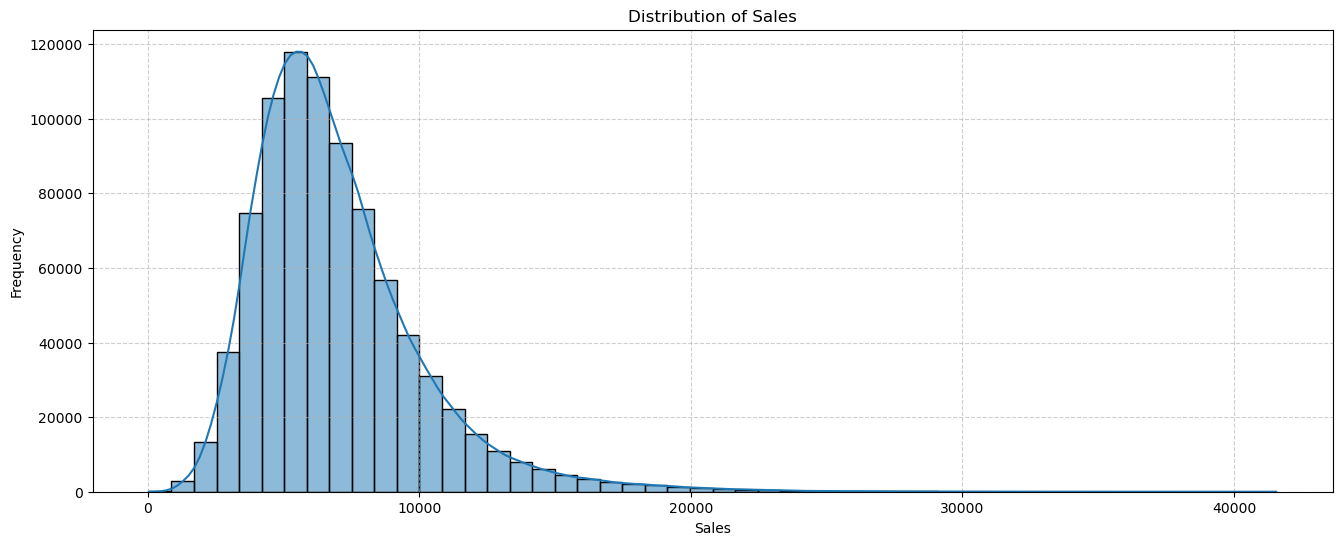

In [30]:
plt.figure(figsize=(16, 6))
sns.histplot(df['Sales'], bins = 50, kde = True)
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [31]:
print(f"Skewness of Sales: {df['Sales'].skew():.2f}")

Skewness of Sales: 1.59


Variable exhibits a strong positive (right-sided) skewness with a skewness coefficient of 1.59. This indicates that the dataset is dominated by standard shopping days with moderate turnover, while featuring a long "right tail" that represents rare days with exceptionally high sales volume.
Highly recommended to experiment with a log transformation of the target variable. 

### Basic statistics for Customers

In [32]:
print(round(df['Customers'].describe(),2))

count    844338.00
mean        762.78
std         401.19
min           8.00
25%         519.00
50%         676.00
75%         893.00
max        7388.00
Name: Customers, dtype: float64


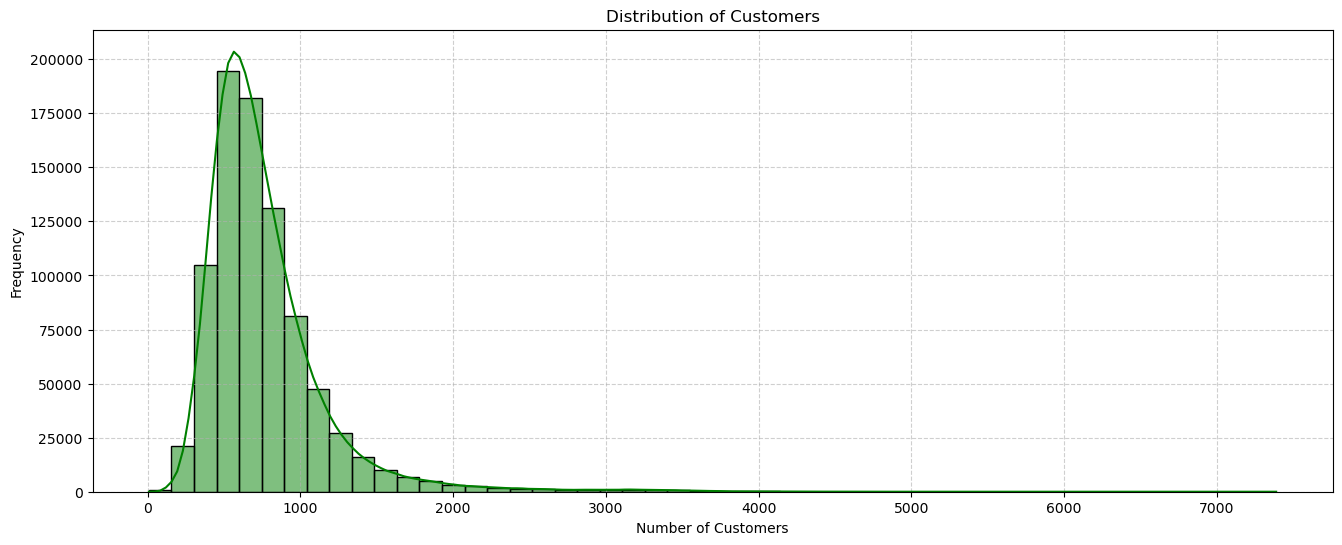

In [33]:
plt.figure(figsize=(16, 6))
sns.histplot(df['Customers'], bins=50, kde=True, color='green')
plt.title('Distribution of Customers')
plt.xlabel('Number of Customers')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [34]:
print(f"Skewness of Sales: {df['Customers'].skew():.2f}")

Skewness of Sales: 2.79


The Customers variable exhibits positive (right-sided) skewness with a remarkably high skewness coefficient of 2.79. The vast majority of the data points are densely concentrated around low-to-moderate daily visitor counts, while the distribution features an exceptionally long and heavy right tail.

## Outlier Identification

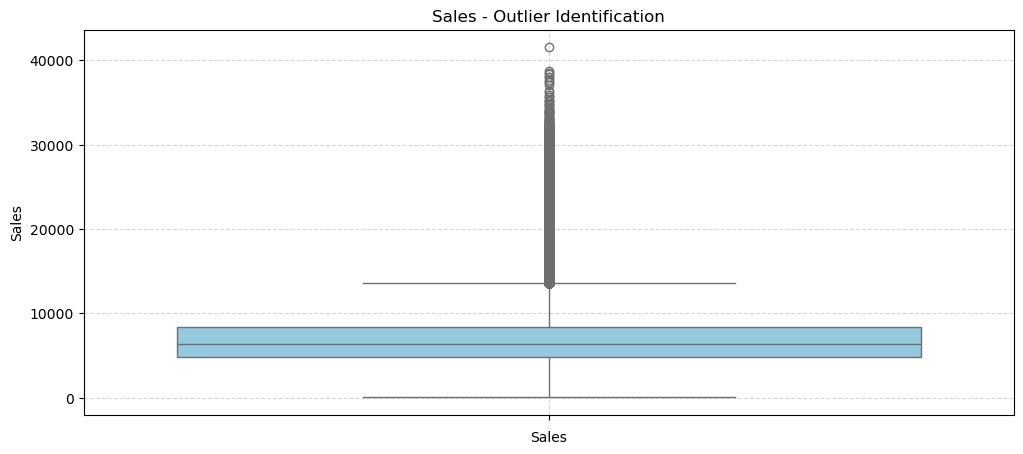

In [35]:
# for Sales
plt.figure(figsize=(12, 5))
sns.boxplot(y=df['Sales'], color='skyblue')
plt.title('Sales - Outlier Identification')
plt.xlabel('Sales')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [36]:
Q1_sales = df['Sales'].quantile(0.25)
Q3_sales = df['Sales'].quantile(0.75)
print(f"Q1_sales:", Q1_sales)
print(f"Q3_sales:", Q3_sales)

Q1_sales: 4859.0
Q3_sales: 8360.0


In [37]:
IQR_sales = Q3_sales - Q1_sales
print(f"IQR_sales:", IQR_sales)

IQR_sales: 3501.0


In [38]:
upper_bound_sales = Q3_sales + 1.5 * IQR_sales
print(upper_bound_sales)
print(f"All data above {upper_bound_sales:.1f} will be categorized as outliers")

13611.5
All data above 13611.5 will be categorized as outliers


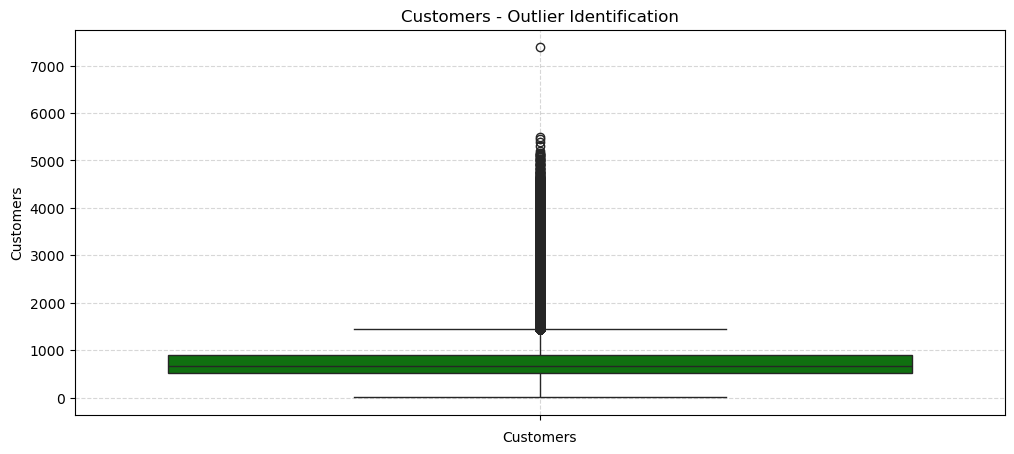

In [39]:
# for Customers
plt.figure(figsize=(12, 5))
sns.boxplot(y=df['Customers'], color='green')
plt.title('Customers - Outlier Identification')
plt.xlabel('Customers')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [40]:
Q1_cust = df['Customers'].quantile(0.25)
Q3_cust = df['Customers'].quantile(0.75)
print(f"Q1_cust:", Q1_cust)
print(f"Q3_cust:", Q3_cust)

Q1_cust: 519.0
Q3_cust: 893.0


In [41]:
IQR_cust = Q3_cust - Q1_cust
print(f"IQR_cust:", IQR_cust)

IQR_cust: 374.0


In [42]:
upper_bound_cust = Q3_cust + 1.5 * IQR_cust
print(upper_bound_cust)
print(f"All data above {upper_bound_cust:.1f} will be categorized as outliers")

1454.0
All data above 1454.0 will be categorized as outliers


In [43]:
# Correlation between Sales & Cusotmers
correlation = df['Customers'].corr(df['Sales'])
print(round(correlation,2))

0.82


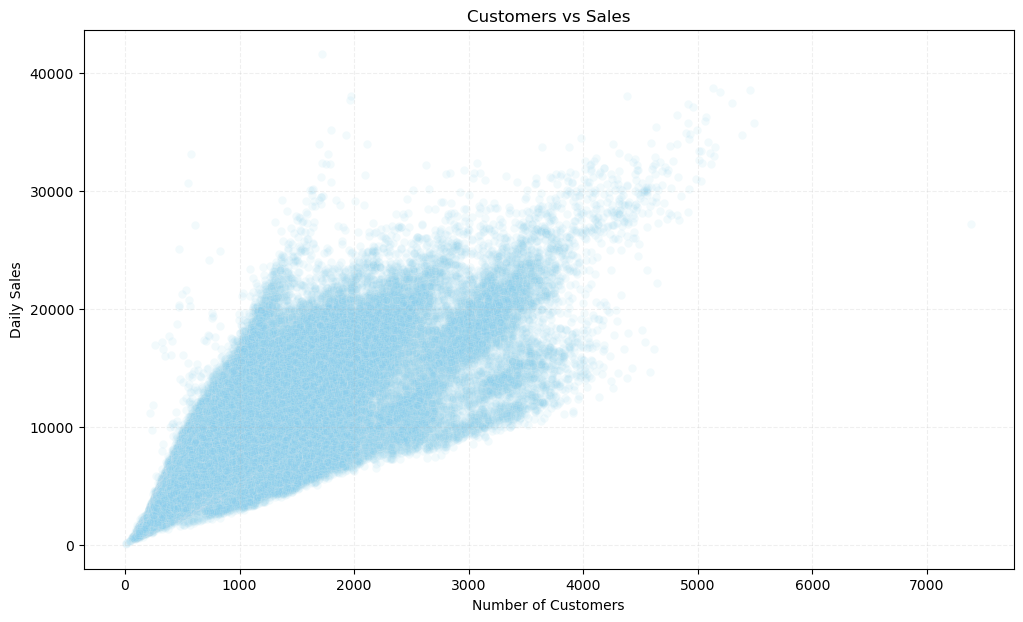

In [44]:
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='Customers', y='Sales', alpha=0.1, color='skyblue')
plt.title(f'Customers vs Sales')
plt.xlabel('Number of Customers')
plt.ylabel('Daily Sales')
plt.grid(True, linestyle='--', alpha=0.2)
plt.show()

Correlation coefficient of 0.82 confirms a positive linear relationship between daily foot traffic and revenue. Increase in customer volume is the primary driver of sales growth.

## Store Closure Analysis & Filtering

In [45]:
closed_stores = df[df['Open'] == 0]

print(f"Total number of records when stores are closed (Open == 0): {closed_stores.shape[0]}")
print(f"Sales during closures: Max = {closed_stores['Sales'].max()}, Min = {closed_stores['Sales'].min()}")
print(f"Customers during closures: Max = {closed_stores['Customers'].max()}, Min = {closed_stores['Customers'].min()}")

Total number of records when stores are closed (Open == 0): 0
Sales during closures: Max = nan, Min = nan
Customers during closures: Max = nan, Min = nan


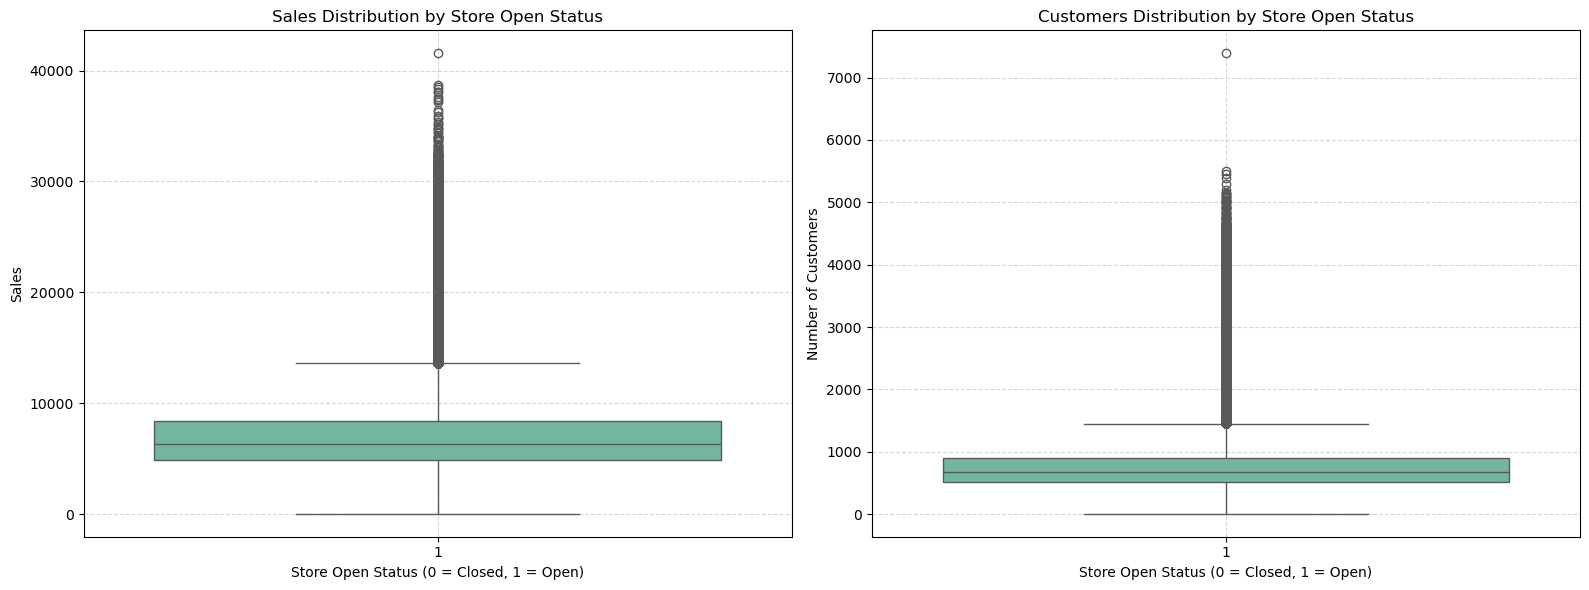

In [46]:
#Sales by Open status
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df, x='Open', y='Sales', hue='Open', ax=axes[0], palette='Set2', legend=False)
axes[0].set_title('Sales Distribution by Store Open Status')
axes[0].set_xlabel('Store Open Status (0 = Closed, 1 = Open)')
axes[0].set_ylabel('Sales')
axes[0].grid(True, linestyle='--', alpha=0.5)


#Customers by Open status
sns.boxplot(data=df, x='Open', y='Customers', ax=axes[1], hue='Open', palette='Set2', legend=False)
axes[1].set_title('Customers Distribution by Store Open Status')
axes[1].set_xlabel('Store Open Status (0 = Closed, 1 = Open)')
axes[1].set_ylabel('Number of Customers')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [47]:
df_train_ready = df[df['Open'] == 1]

print(f"Dataset shape before removing closed stores: {df.shape}")
print(f"Dataset shape after removing closed stores (Ready for Training): {df_train_ready.shape}")

Dataset shape before removing closed stores: (844338, 22)
Dataset shape after removing closed stores (Ready for Training): (844338, 22)


## Impact of categorical variables on daily sales

This analysis examines how promotions and holidays influence daily sales volume across Rossmann stores.

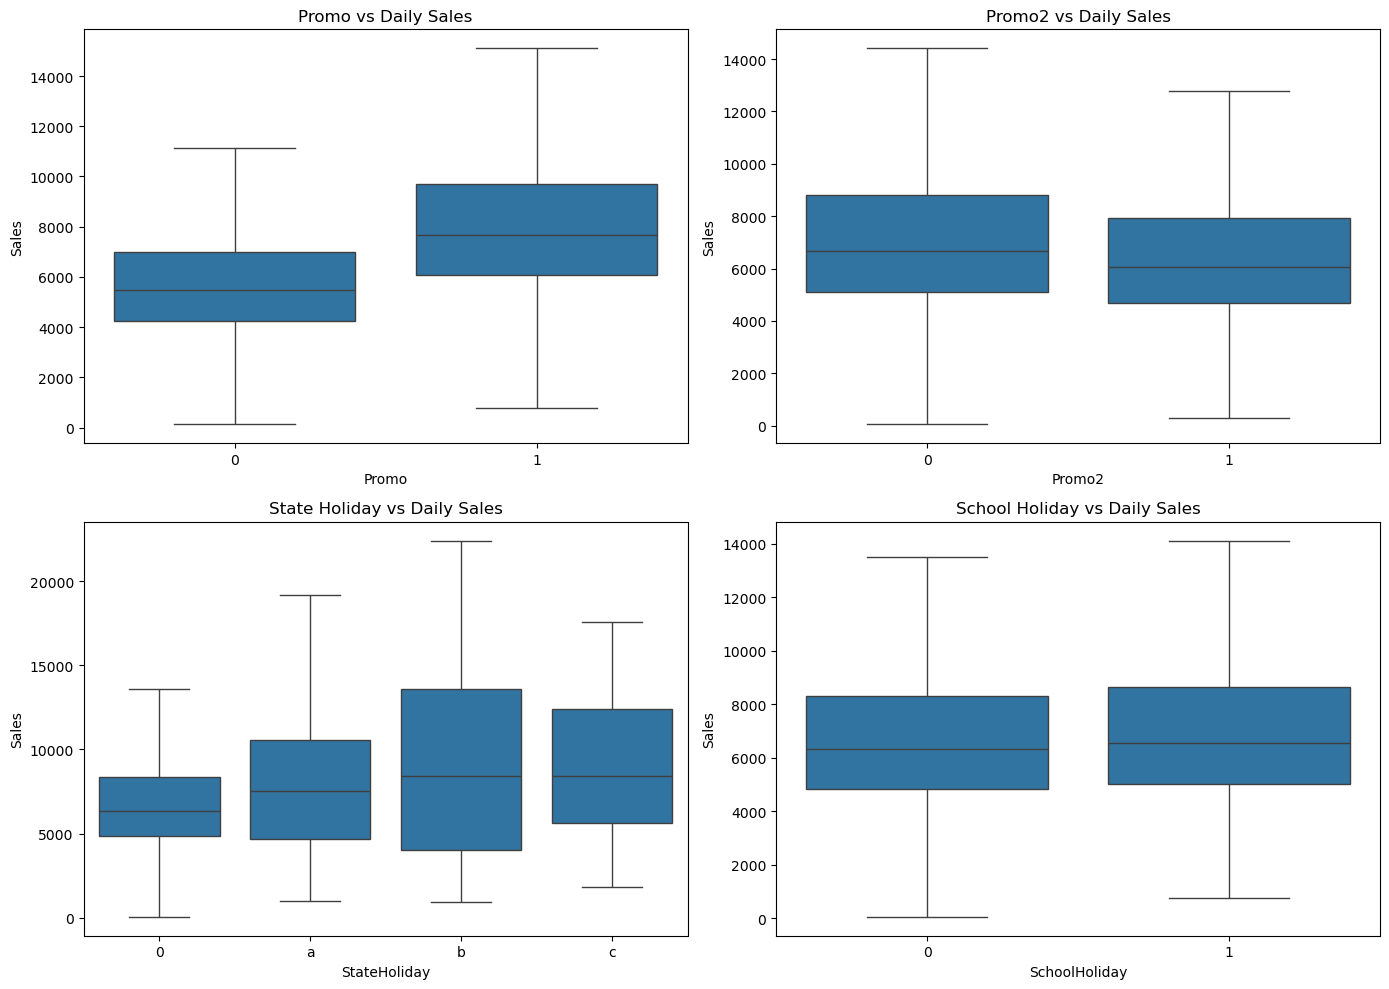

In [48]:
# Visualize the impact of promotional activities and holidays on sales distribution

fig, axes = plt.subplots(2, 2, figsize = (14, 10))

sns.boxplot(data = df, x = 'Promo', y = 'Sales', ax = axes[0, 0], showfliers = False)
axes[0, 0].set_title('Promo vs Daily Sales')

sns.boxplot(data = df, x = 'Promo2', y = 'Sales', ax = axes[0, 1], showfliers = False)
axes[0, 1].set_title('Promo2 vs Daily Sales')

sns.boxplot(data = df, x = 'StateHoliday', y = 'Sales', ax = axes[1, 0], showfliers = False)
axes[1, 0].set_title('State Holiday vs Daily Sales')

sns.boxplot(data = df, x = 'SchoolHoliday', y = 'Sales', ax = axes[1, 1], showfliers = False)
axes[1, 1].set_title('School Holiday vs Daily Sales')

plt.tight_layout()
plt.show()

In [49]:
# Calculate average sales for each category

print("Average sales by Promo:")
display(df.groupby('Promo')['Sales'].mean())

print("Average sales by Promo2:")
display(df.groupby('Promo2')['Sales'].mean())

print("Average sales by StateHoliday:")
display(df.groupby('StateHoliday')['Sales'].mean())

print("Average sales by SchoolHoliday:")
display(df.groupby('SchoolHoliday')['Sales'].mean())

Average sales by Promo:


Promo
0    5929.826183
1    8228.739731
Name: Sales, dtype: float64

Average sales by Promo2:


Promo2
0    7350.818414
1    6558.993542
Name: Sales, dtype: float64

Average sales by StateHoliday:


StateHoliday
0    6702.687531
0    6992.483936
a    8487.471182
b    9887.889655
c    9743.746479
Name: Sales, dtype: float64

Average sales by SchoolHoliday:


SchoolHoliday
0    6897.207830
1    7200.710282
Name: Sales, dtype: float64

### Key findings

- Promotions significantly influence demand and should be considered by the forecasting model when planning inventory levels.

- State holidays affect sales volume differently depending on holiday type.
- School holidays influence customer purchasing behavior.
- Participation in the Promo2 program is associated with changes in average sales levels.

<h1 style="text-align:left;">
Sales Trend and Seasonality Analysis
</h1>

Seasonality is analyzed at three temporal levels: year (month of year), month (week of month), and week (day of week).

In [50]:
print(df['Date'].dtype)

datetime64[us]


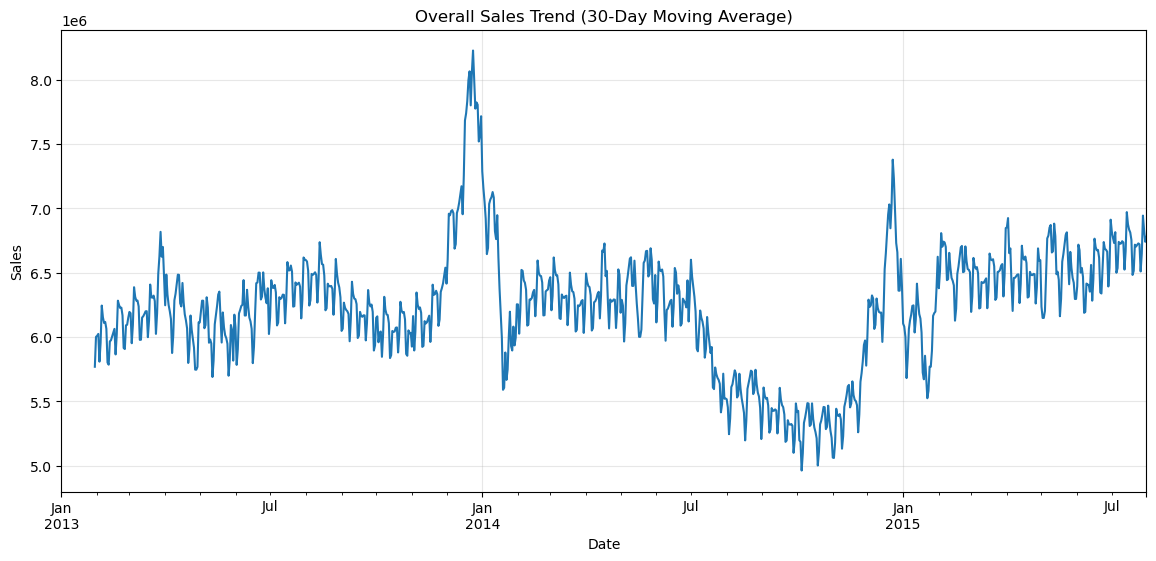

In [51]:
# Sales Trend analysis: 30-day moving average sales trend

daily_sales = df.groupby('Date')['Sales'].sum()

trend = daily_sales.rolling(window=30).mean()

plt.figure(figsize=(14,6))
trend.plot()

plt.title('Overall Sales Trend (30-Day Moving Average)')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.grid(alpha=0.3)

plt.show()

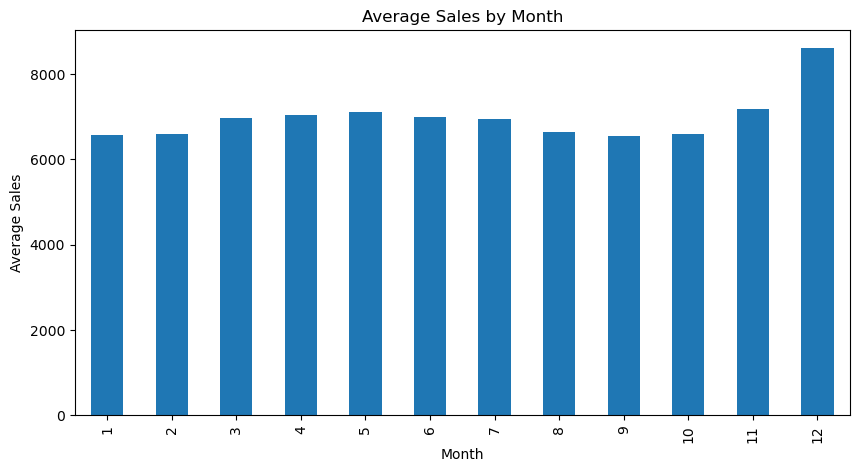

In [52]:
# Annual seasonality Analysis: Average sales by month (to identify seasonal patterns)

monthly_pattern = (df.groupby(df['Date'].dt.month)['Sales'].mean())

plt.figure(figsize=(10,5))
monthly_pattern.plot(kind='bar')

plt.title('Average Sales by Month')
plt.xlabel('Month')
plt.ylabel('Average Sales')

plt.show()

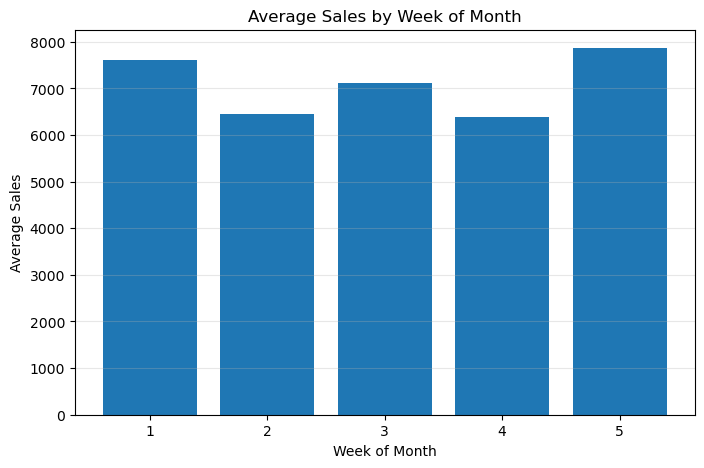

In [53]:
#Monthly seasonality analysis: Average sales by week of month (to identify intra-month patterns)

df['WeekOfMonth'] = ((df['Date'].dt.day - 1) // 7) + 1

monthly_pattern = (df.groupby('WeekOfMonth')['Sales'].mean())

plt.figure(figsize=(8, 5))
plt.bar( monthly_pattern.index, monthly_pattern.values)

plt.title('Average Sales by Week of Month')
plt.xlabel('Week of Month')
plt.ylabel('Average Sales')

plt.xticks([1, 2, 3, 4, 5])
plt.grid(axis='y', alpha=0.3)

plt.show()

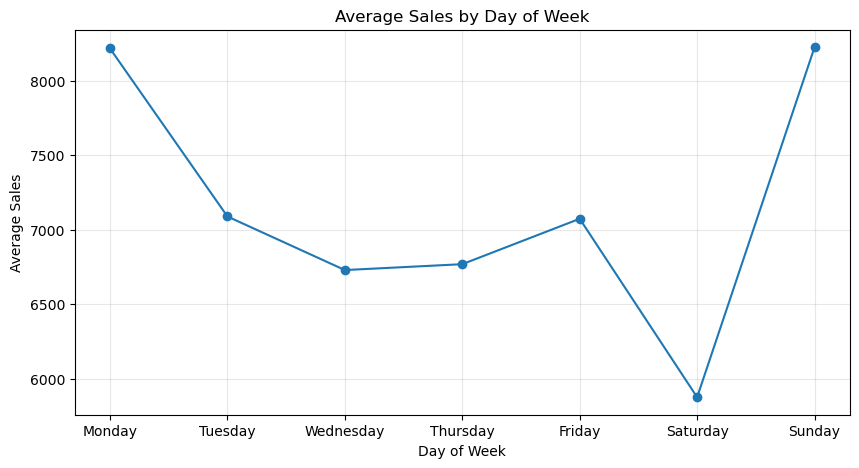

In [54]:
# Weekly seasonality Analysis: Average sales by day of week (to identify weekly patterns)

day_order = ['Monday', 'Tuesday', 'Wednesday','Thursday', 'Friday', 'Saturday', 'Sunday']

weekly_sales = (df.assign(DayOfWeek=df['Date'].dt.day_name()).groupby('DayOfWeek')['Sales'].mean().reindex(day_order))

plt.figure(figsize=(10, 5))
plt.plot(weekly_sales.index, weekly_sales.values, marker='o')

plt.title('Average Sales by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Sales')

plt.grid(alpha=0.3)

plt.show()

Key Findings: 

- Clear trend and seasonal effects are present in the sales data.
- December records the highest average sales, highlighting annual seasonality.
- Sales levels differ across weeks within a month, indicating monthly seasonality.
- Demand is strongest on Sundays and Mondays and weakest on Saturdays.
- Time-based features are likely to provide predictive value for forecasting models.

## Time-Based Splitting Strategy: Window Analysis

In [55]:
train['Date'] = pd.to_datetime(train['Date'])

train_min_date = train['Date'].min()
train_max_date = train['Date'].max()
train_duration = (train_max_date - train_min_date).days

print(f"train_min_date: {train_min_date}")
print(f"train_max_date: {train_max_date}")
print(f"train.csv duration: {train_duration} days")

train_min_date: 2013-01-01 00:00:00
train_max_date: 2015-07-31 00:00:00
train.csv duration: 941 days


In [56]:
test = pd.read_csv("../data/test.csv")


test['Date'] = pd.to_datetime(test['Date'])

test_min_date = test['Date'].min()
test_max_date = test['Date'].max()
test_duration = (test_max_date - test_min_date).days

print(test_min_date)
print(test_max_date)
print(f"test.csv duration: {test_duration} days")

2015-08-01 00:00:00
2015-09-17 00:00:00
test.csv duration: 47 days


In [57]:
## Missing one day in test.csv duration

In [58]:
test['Date'] = pd.to_datetime(test['Date'])

test_min_date = test['Date'].min()
test_max_date = test['Date'].max()
test_duration = (test_max_date - test_min_date).days + 1

print(f"test.csv duration: {test_duration} days")

test.csv duration: 48 days


48 days / 7 days = 6 full weeks + 6 days extra. This means 6-week forecasting window.
Acc to Kaggle: In their first Kaggle competition, Rossmann is challenging you to predict 6 weeks of daily sales for 1,115 stores located across Germany.

## Calendar Feature Extraction

In [59]:
df_train_ready = df_train_ready.copy()

In [60]:
df_train_ready['Year'] = df_train_ready['Date'].dt.year
df_train_ready['Month'] = df_train_ready['Date'].dt.month
df_train_ready['Day'] = df_train_ready['Date'].dt.day
df_train_ready['DayOfWeek'] = df_train_ready['Date'].dt.dayofweek
df_train_ready['WeekOfYear'] = df_train_ready['Date'].dt.isocalendar().week.astype(int)
df_train_ready['IsWeekend'] = df_train_ready['Date'].dt.dayofweek.isin([5, 6]).astype(int)

In [61]:
print("Extracted calendar features summary:")
display(df_train_ready[['Date', 'Year', 'Month', 'Day', 'DayOfWeek', 'WeekOfYear', 'IsWeekend']].head())

Extracted calendar features summary:


,Date,Year,Month,Day,DayOfWeek,WeekOfYear,IsWeekend
0,2015-07-31,2015,7,31,4,31,0
1,2015-07-31,2015,7,31,4,31,0
2,2015-07-31,2015,7,31,4,31,0
3,2015-07-31,2015,7,31,4,31,0
4,2015-07-31,2015,7,31,4,31,0


In [62]:
print("\nWeekend vs Weekday record count:")
display(df_train_ready['IsWeekend'].value_counts())


Weekend vs Weekday record count:


IsWeekend
0    696693
1    147645
Name: count, dtype: int64

In [63]:
print("\nAverage sales: Weekdays (0) vs Weekends (1):")
display(df_train_ready.groupby('IsWeekend')['Sales'].mean())


Average sales: Weekdays (0) vs Weekends (1):


IsWeekend
0    7172.903208
1    5932.264337
Name: Sales, dtype: float64

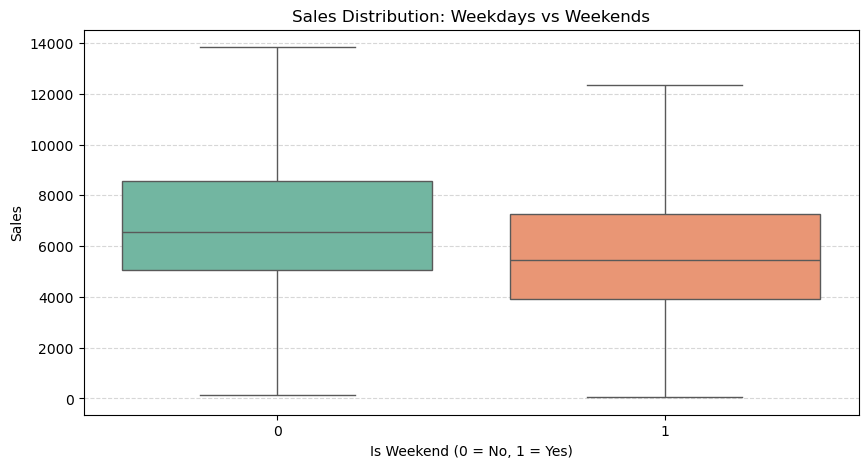

In [64]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_train_ready, x='IsWeekend', y='Sales', hue='IsWeekend', showfliers=False, palette='Set2', legend=False)
plt.title('Sales Distribution: Weekdays vs Weekends')
plt.xlabel('Is Weekend (0 = No, 1 = Yes)')
plt.ylabel('Sales')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

### Conclusion

- Weekday sales are higher than weekend sales.
- Weekend sales have a lower median and overall distribution.
- The 'IsWeekend' feature captures weekly demand patterns and may improve demand forecasting performance.

## Lag Feature Generation

In [65]:
# Create a copy for lag feature engineering

df_train_ready = df_train_ready.copy()

In [66]:
# Sort data before creating lag features

df_train_ready = df_train_ready.sort_values(["Store", "Date"])

In [67]:
# Generate lag features

df_train_ready["Sales_Lag_49"] = (df_train_ready.groupby("Store")["Sales"].shift(49))

df_train_ready["Sales_Lag_56"] = (df_train_ready.groupby("Store")["Sales"].shift(56))

In [68]:
print("Lag features created:")
display(
    df_train_ready[
        ["Store", "Date", "Sales", "Sales_Lag_49", "Sales_Lag_56"]
    ].head(15))

Lag features created:


,Store,Date,Sales,Sales_Lag_49,Sales_Lag_56
1014980,1,2013-01-02,5530,NaN,NaN
1013865,1,2013-01-03,4327,NaN,NaN
1012750,1,2013-01-04,4486,NaN,NaN
1011635,1,2013-01-05,4997,NaN,NaN
1009405,1,2013-01-07,7176,NaN,NaN
1008290,1,2013-01-08,5580,NaN,NaN
1007175,1,2013-01-09,5471,NaN,NaN
1006060,1,2013-01-10,4892,NaN,NaN
1004945,1,2013-01-11,4881,NaN,NaN
1003830,1,2013-01-12,4952,NaN,NaN


In [69]:
print("Missing values in lag features:")

display(df_train_ready[["Sales_Lag_49", "Sales_Lag_56"]].isna().sum())

print("Lag feature summary:")

display(df_train_ready[["Sales_Lag_49", "Sales_Lag_56"]].describe())

Missing values in lag features:


Sales_Lag_49    54635
Sales_Lag_56    62440
dtype: int64

Lag feature summary:


,Sales_Lag_49,Sales_Lag_56
count,789703.000000,781898.000000
mean,6952.091363,6942.993246
std,3108.675926,3106.030447
min,46.000000,46.000000
25%,4851.000000,4845.000000
50%,6365.000000,6355.000000
75%,8357.000000,8345.000000
max,38722.000000,38722.000000


## Conclusion
- Lag features for 49 and 56 days were successfully created.
- Missing values occur only at the beginning of each store's time series, which is expected.
- Previous sales values will provide historical information and may improve forecasting performance.

## Rolling Window Feature Generation

In [70]:
df_train_ready = df_train_ready.copy()
df_train_ready = df_train_ready.sort_values(["Store", "Date"])

In [71]:
df_train_ready["Sales_Rolling_Mean_14"] = (
    df_train_ready.groupby("Store")["Sales"]
    .transform(lambda x: x.shift(49)
    .rolling(window=14, min_periods=1).mean()))

In [72]:
df_train_ready["Sales_Rolling_Mean_30"] = (
    df_train_ready.groupby("Store")["Sales"]
    .transform(lambda x: x.shift(49)
    .rolling(window=30, min_periods=1).mean()))

In [73]:
df_train_ready["Sales_Rolling_Std_14"] = (
    df_train_ready.groupby("Store")["Sales"]
    .transform(lambda x: x.shift(49).rolling(window=14, min_periods=1).std()))

In [74]:
df_train_ready["Sales_Rolling_Median_14"] = (
    df_train_ready.groupby("Store")["Sales"]
    .transform(lambda x: x.shift(49).rolling(window=14, min_periods=1).median()))

## Time-Based Train/Test Split

To avoid data leakage in time series forecasting, the dataset is split chronologically. Earlier observations are used for training, while the most recent observations are reserved for validation.


In [75]:
# Sort dataset chronologically by date

df_train_ready = df_train_ready.sort_values('Date')

# Create train and validation datasets using a fixed cutoff date

split_date = '2015-06-15'

train_data = df_train_ready[df_train_ready['Date'] < split_date]
validation_data = df_train_ready[df_train_ready['Date'] >= split_date]

# Display split information

print(f"Training dataset shape: {train_data.shape}")
print(f"Validation dataset shape: {validation_data.shape}")

print(f"\nTraining period:")
print(f"{train_data['Date'].min()} -> {train_data['Date'].max()}")

print(f"\nValidation period:")
print(f"{validation_data['Date'].min()} -> {validation_data['Date'].max()}")

Training dataset shape: (798486, 29)
Validation dataset shape: (45852, 29)

Training period:
2013-01-01 00:00:00 -> 2015-06-14 00:00:00

Validation period:
2015-06-15 00:00:00 -> 2015-07-31 00:00:00


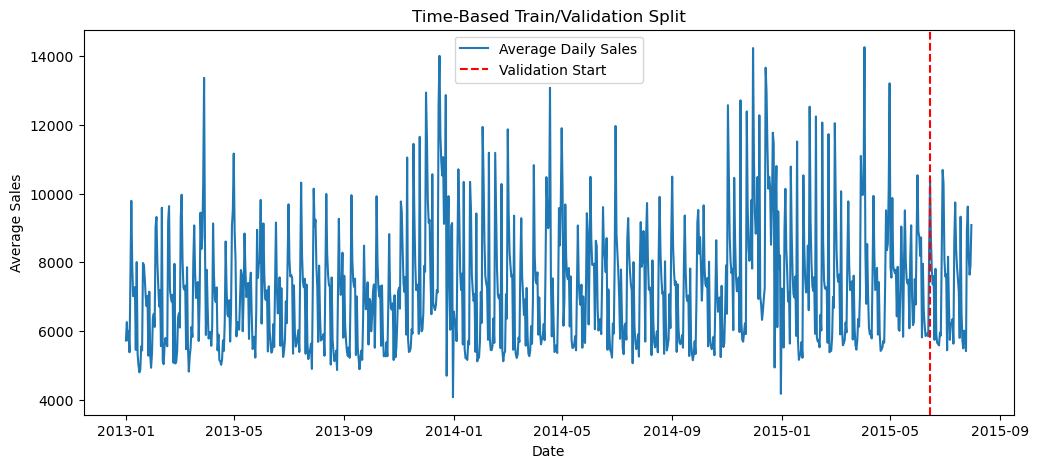

In [76]:
# Visualize the train-validation split

plt.figure(figsize=(12, 5))

plt.plot(
    df_train_ready.groupby('Date')['Sales'].mean(),
    label='Average Daily Sales'
)

plt.axvline(
    pd.Timestamp(split_date),
    color='red',
    linestyle='--',
    label='Validation Start'
)

plt.title('Time-Based Train/Validation Split')
plt.xlabel('Date')
plt.ylabel('Average Sales')
plt.legend()

plt.show()

### Split Summary

The dataset was divided chronologically using a fixed cutoff date (2015-06-15). Historical observations were assigned to the training set, while the most recent observations were reserved for validation. This approach prevents data leakage and better reflects real-world sales forecasting scenarios.

## Pipeline

In [77]:
# Split the dataset into features and target variable

X_train = train_data.drop(columns=['Sales', 'Customers', 'Date'])
y_train = train_data['Sales']

X_val = validation_data.drop(columns=['Sales', 'Customers', 'Date'])
y_val = validation_data['Sales']

In [78]:
#Split data to num i cat.
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'string', 'category']).columns.tolist()

X_train_clean = X_train.copy()
X_val_clean = X_val.copy()

In [79]:
for col in cat_cols:
    X_train_clean[col] = X_train_clean[col].astype(str)
    X_val_clean[col] = X_val_clean[col].astype(str)

In [80]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_cols),
        ('cat', Pipeline(steps=[
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_cols)
    ])

In [81]:
preprocessor.fit(X_train_clean)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Store', 'Open', 'Promo', 'SchoolHoliday',
                                  'CompetitionDistance',
                                  'CompetitionOpenSinceMonth',
                                  'CompetitionOpenSinceYear', 'Promo2',
                                  'Promo2SinceWeek', 'Promo2SinceYear',
                                  'WeekOfYear', 'IsWeekend', 'Sales_Lag_49',
                                  'Sales_Lag_56', 'Sales_Rolling_Mean_14',
                                  'Sales_Rolling_Mean_30',
                                  'Sales_Rolling_Std_14',
                                  'Sales_Rolling_Median_14']),
                                ('cat',
                                 Pipeline(steps=[('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['StateHoliday', 'StoreType', 'Assortment',
                                  'PromoInterval'])])

In [82]:
X_train_processed = preprocessor.transform(X_train_clean)
X_val_processed = preprocessor.transform(X_val_clean)

## Baseline heuristic model

In [83]:
recent_train = train_data[train_data['Date'] >= '2015-05-01']

In [84]:
baseline_rules = recent_train.groupby(['Store', 'DayOfWeek'])['Sales'].mean().reset_index()
baseline_rules.rename(columns={'Sales': 'Baseline_Predicted_Sales'}, inplace=True)

In [85]:
baseline_rules

,Store,DayOfWeek,Baseline_Predicted_Sales
0,1,0,4853.400000
1,1,1,4518.166667
2,1,2,4529.333333
3,1,3,4005.500000
4,1,4,4509.166667
...,...,...,...
6718,1115,1,6872.500000
6719,1115,2,7251.166667
6720,1115,3,6292.250000
6721,1115,4,7962.000000


In [86]:
validation_baseline = validation_data.merge(baseline_rules, on=['Store', 'DayOfWeek'], how='left')
validation_baseline

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,Day,WeekOfYear,IsWeekend,Sales_Lag_49,Sales_Lag_56,Sales_Rolling_Mean_14,Sales_Rolling_Mean_30,Sales_Rolling_Std_14,Sales_Rolling_Median_14,Baseline_Predicted_Sales
0,996,0,2015-06-15,13486,1111,1,1,0,0,c,...,15,25,0,7193.0,7094.0,8481.571429,7632.566667,3441.110034,7143.5,9876.800000
1,1069,0,2015-06-15,9880,983,1,1,0,0,a,...,15,25,0,9043.0,7095.0,7559.142857,6895.033333,2720.988956,7565.5,7996.200000
2,9,0,2015-06-15,11530,856,1,1,0,0,a,...,15,25,0,8416.0,8664.0,8214.214286,7612.833333,2021.678746,7701.5,9865.000000
3,940,0,2015-06-15,11378,1033,1,1,0,0,d,...,15,25,0,7810.0,8047.0,8787.071429,7856.200000,2431.822155,8273.0,9304.200000
4,132,0,2015-06-15,10259,828,1,1,0,0,d,...,15,25,0,8127.0,9740.0,8274.642857,7471.900000,2029.701668,7908.0,7846.600000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45847,1093,4,2015-07-31,11778,1071,1,1,0,1,c,...,31,31,0,9252.0,8250.0,9362.214286,9220.400000,1458.648488,9047.0,9532.333333
45848,349,4,2015-07-31,9281,873,1,1,0,1,c,...,31,31,0,8871.0,8745.0,9163.428571,9363.800000,754.803053,9081.5,8794.500000
45849,419,4,2015-07-31,8159,1030,1,1,0,1,c,...,31,31,0,6093.0,4700.0,6071.071429,6178.900000,1284.282527,5879.5,5799.333333
45850,476,4,2015-07-31,7562,748,1,1,0,1,d,...,31,31,0,7216.0,5668.0,6464.500000,6513.400000,1848.003070,6736.0,6324.333333


In [87]:
global_mean = train_data['Sales'].mean()
validation_baseline['Baseline_Predicted_Sales'] = validation_baseline['Baseline_Predicted_Sales'].fillna(global_mean)

In [88]:
print(validation_baseline[['Date', 'Store', 'DayOfWeek', 'Sales', 'Baseline_Predicted_Sales']].head())

        Date  Store  DayOfWeek  Sales  Baseline_Predicted_Sales
0 2015-06-15    996          0  13486                    9876.8
1 2015-06-15   1069          0   9880                    7996.2
2 2015-06-15      9          0  11530                    9865.0
3 2015-06-15    940          0  11378                    9304.2
4 2015-06-15    132          0  10259                    7846.6


In [89]:
y_pred_baseline = validation_baseline['Baseline_Predicted_Sales'].values
y_true_baseline = validation_baseline['Sales'].values

## Metrics

In [90]:
# Mean Absolute Error
def calculate_mae(y_true, y_pred):
    mask = y_true != 0
    return mean_absolute_error(y_true[mask], y_pred[mask])

In [91]:
# Mean Absolute Percentage Error
def calculate_mape(y_true, y_pred):
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

In [92]:
# Root Mean Square Percentage Error
def calculate_rmspe(y_true, y_pred):
    mask = y_true != 0
    return np.sqrt(np.mean(((y_true[mask] - y_pred[mask]) / y_true[mask]) ** 2)) * 100

In [93]:
# Calculate baseline evaluation metrics
mae_val = calculate_mae(y_true_baseline, y_pred_baseline)
mape_val = calculate_mape(y_true_baseline, y_pred_baseline)
rmspe_val = calculate_rmspe(y_true_baseline, y_pred_baseline)
rmse_val = root_mean_squared_error(y_true_baseline, y_pred_baseline)
r2_val = r2_score(y_true_baseline, y_pred_baseline)


### Baseline model metrics

In [94]:
print(f"MAE {mae_val:.2f} EUR")
print(f"MAPE {mape_val:.2f}%")
print(f"RMSPE {rmspe_val:.2f}%")
print(f"RMSE {rmse_val:.2f}")
print(f"R2 {r2_val:.2f}")

MAE 1257.47 EUR
MAPE 18.81%
RMSPE 23.90%
RMSE 1623.85
R2 0.72


## Baseline Model Evaluation

To establish a reference point for future models, a simple baseline model is evaluated. The obtained error metrics will be used to compare the performance of more advanced machine learning models.

In [95]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score)

In [96]:
# Train a baseline model predicting the average sales value

baseline_model = DummyRegressor(strategy="mean")

baseline_model.fit(X_train_processed, y_train)

baseline_predictions = baseline_model.predict(X_val_processed)

In [97]:
# Calculate baseline error metrics

mae = mean_absolute_error(y_val, baseline_predictions)
rmse = root_mean_squared_error(y_val, baseline_predictions)
r2 = r2_score(y_val, baseline_predictions)
mape = calculate_mape(y_val, baseline_predictions)
rmspe = calculate_rmspe(y_val, baseline_predictions)

print(f"Baseline MAE : {mae:.2f}")
print(f"Baseline RMSE: {rmse:.2f}")
print(f"Baseline R²  : {r2:.4f}")
print(f"Baseline MAPE: {mape:.4f}")
print(f"Baseline RMSPE: {rmspe:.4f}")

Baseline MAE : 2263.37
Baseline RMSE: 3095.58
Baseline R²  : -0.0042
Baseline MAPE: 36.9649
Baseline RMSPE: 55.6864


In [98]:
# Store baseline metrics for future comparison

baseline_results = pd.DataFrame({
    "Model": ["Baseline (DummyRegressor)"],
    "MAE": [mae],
    "RMSE": [rmse],
    "R2": [r2],
    "MAPE": [mape],
    "RMSPE": [rmspe]})

display(baseline_results)

,Model,MAE,RMSE,R2,MAPE,RMSPE
0,Baseline (DummyRegressor),2263.372327,3095.583376,-0.004164,36.964948,55.686438


### Conclusion

The DummyRegressor establishes a baseline performance benchmark for the demand forecasting task. Future machine learning models will be evaluated against this benchmark using MAE, RMSE, MAPE, RMSPE, and R². An effective forecasting model should reduce prediction errors while improving the explained variance, providing more accurate demand estimates to support inventory planning and production decisions.

# RandomForestRegressor

In [99]:
# Mostly code commented due to time of performance - results can be found in summary folder

In [100]:
y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)

In [101]:
# rf_model_default = RandomForestRegressor(
#     n_estimators=100,      
#     random_state=42,      
#     n_jobs=-1,             
#     verbose=1              
# )

In [102]:
#rf_model_default.fit(X_train_processed, y_train_log)

In [103]:
# rf_pred_log_default = rf_model_default.predict(X_val_processed)

In [104]:
# rf_pred_default = np.expm1(rf_pred_log_default)

In [105]:
# rf_default_mae = mean_absolute_error(y_val, rf_pred_default)
# rf_default_rmse = root_mean_squared_error(y_val, rf_pred_default)
# rf_default_r2 = r2_score(y_val, rf_pred_default)
# rf_default_mape = calculate_mape(y_val, rf_pred_default)
# rf_default_rmspe = calculate_rmspe(y_val, rf_pred_default)

# print("\nDefault RandomForest metrics")
# print(f"MAE  : {rf_default_mae:.2f} EUR")
# print(f"RMSE : {rf_default_rmse:.2f} EUR")
# print(f"R²   : {rf_default_r2:.4f}")
# print(f"MAPE : {rf_default_mape:.4f}")
# print(f"RMSPE: {rf_default_rmspe:.4f}")

In [106]:
# Parameters tunning

In [107]:
# param_distributions = {
#     'n_estimators': [100, 150],          
#     'max_depth': [15, 20, 25],           
#     'min_samples_split': [5, 10],        
#     'min_samples_leaf': [2, 4]           
# }

In [108]:
# rf_random_search = RandomizedSearchCV(
#     estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
#     param_distributions=param_distributions,
#     n_iter=4,
#     cv=3,
#     scoring='neg_mean_absolute_error',
#     random_state=42,
#     n_jobs=-1,
#     verbose=1
# )

In [109]:
# rf_random_search.fit(X_train_processed, y_train_log)

# print("Best parameters found", rf_random_search.best_params_)
# best_rf_model = rf_random_search.best_estimator_

In [110]:
# rf_pred_log_tuned = best_rf_model.predict(X_val_processed)
# rf_pred_tuned = np.expm1(rf_pred_log_tuned)

In [111]:
# rf_tuned_mae = mean_absolute_error(y_val, rf_pred_tuned)
# rf_tuned_rmse = root_mean_squared_error(y_val, rf_pred_tuned)
# rf_tuned_r2 = r2_score(y_val, rf_pred_tuned)
# rf_tuned_mape = calculate_mape(y_val, rf_pred_tuned)
# rf_tuned_rmspe = calculate_rmspe(y_val, rf_pred_tuned)

In [112]:
# new_results = pd.DataFrame({
#     "Model": [
#         "Heuristic model", 
#         "RandomForest (Default)", 
#         "RandomForest (Tuned)"
#     ],
#     "MAE": [mae_val, rf_default_mae, rf_tuned_mae],
#     "RMSE": [rmse_val, rf_default_rmse, rf_tuned_rmse],
#     "R2": [r2_val, rf_default_r2, rf_tuned_r2],
#     "MAPE": [mape_val, rf_default_mape, rf_tuned_mape],
#     "RMSPE": [rmspe_val, rf_default_rmspe, rf_tuned_rmspe]
# })

In [113]:
# final_comparison = pd.concat([baseline_results, new_results], ignore_index=True)

In [114]:
# print("So far model comparsion")
# display(final_comparison)

1. OVERALL MODEL PERFORMANCE & BENCHMARKING:
--------------------------------------------------------------------------------
- DummyRegressor (Baseline):
  Performed poorly with a MAPE of 36.96% and an R² close to zero (-0.0042). 
  This confirms that predicting a global flat mean provides zero explanatory 
  power for retail sales variation.

- Heuristic Model 
  Showed a massive improvement, dropping the MAPE to 18.81% and reaching an 
  R² of 0.7236. This proves that capturing store-specific traffic habits and 
  weekly retail seasonality (e.g., higher sales on Mondays/Fridays, lower on 
  Sundays) serves as an incredibly robust baseline rule.

- RandomForestRegressor (Default vs Tuned):
  The Machine Learning approach significantly outperformed the heuristic rules. 
  The default Random Forest reduced the MAPE further to 12.82%, while the 
  Hyperparameter-Tuned Random Forest achieved the best overall performance 
  across all evaluation metrics:
    * MAE   : 898.63 EUR (On average, error dropped by ~359 EUR per store/day vs Heuristics)
    * R²    : 0.8281     (The model successfully explains 82.81% of data variance)
    * MAPE  : 12.80%     (Average percentage error)
    * RMSPE : 17.06%     (The primary competition metric)

2. IMPACT OF HYPERPARAMETER TUNING:
--------------------------------------------------------------------------------
- Running RandomizedSearchCV with explicit regularizations (limiting max_depth 
  and increasing min_samples_leaf/split) yielded systematic improvements.
- Most importantly, the competition metric (RMSPE) dropped from 17.09% to 17.06%. 
  Since RMSPE penalizes large outliers severely due to squaring percentage errors, 
  this decrease proves that the tuned model generalizes better and generates 
  fewer extreme mispredictions.

In [115]:
# final_comparison.to_csv("metrics_summary.csv", index=False)

# Loading results after randomforestregressor

In [132]:
try:
    final_comparison = pd.read_csv("../summary/metrics_summary.csv")
except FileNotFoundError:
    print("File metrics_summary.csv not found")
    
print("Uptodate comparison")
display(final_comparison)

Uptodate comparison


,Model,MAE,RMSE,R2,MAPE,RMSPE
0,Baseline (DummyRegressor),2263.372327,3095.583376,-0.004164,36.964948,55.686438
1,Heuristic model,1257.466100,1623.845744,0.723682,18.810114,23.895462
2,RandomForest (Default),900.017923,1282.907584,0.827531,12.822350,17.088011
3,RandomForest (Tuned),898.633622,1280.809084,0.828095,12.797232,17.056614


## SVR Initialization and Data Preparation

In [133]:
X_train_processed = preprocessor.transform(X_train_clean)
X_val_processed = preprocessor.transform(X_val_clean)
y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)

np.random.seed(42)
sample_indices = np.random.choice(X_train_processed.shape[0], size=50000, replace=False)

X_train_sample = X_train_processed[sample_indices]
y_train_log_sample = y_train_log.iloc[sample_indices]

In [134]:
svr_default = LinearSVR(dual="auto", max_iter=10000, random_state=42)
svr_default.fit(X_train_sample, y_train_log_sample)

LinearSVR(max_iter=10000, random_state=42)

In [135]:
preds_def_log = svr_default.predict(X_val_processed)
preds_default = np.clip(np.expm1(preds_def_log), 0, None)

In [136]:
svr_def_mae = calculate_mae(y_val, preds_default)
svr_def_rmse = root_mean_squared_error(y_val, preds_default)
svr_def_r2 = r2_score(y_val, preds_default)
svr_def_mape = calculate_mape(y_val, preds_default)
svr_def_rmspe = calculate_rmspe(y_val, preds_default)

# SVR Model Fitting and Caching

In [137]:
param_distributions = {
    'C': [0.1, 1.0, 10.0],
    'epsilon': [0.0, 0.05, 0.1],
    'loss': ['epsilon_insensitive', 'squared_epsilon_insensitive']
}

In [139]:
svr_random_search = RandomizedSearchCV(
    estimator=LinearSVR(dual="auto", max_iter=10000, random_state=42),
    param_distributions=param_distributions,
    n_iter=4, 
    cv=3,     
    scoring='neg_mean_absolute_error',
    n_jobs=-1, 
    random_state=42,
    verbose=1
)
svr_random_search.fit(X_train_sample, y_train_log_sample)
print(f"Best found parameters {svr_random_search.best_params_}")

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best found parameters {'loss': 'epsilon_insensitive', 'epsilon': 0.05, 'C': 1.0}


In [140]:
svr_tuned = svr_random_search.best_estimator_
preds_tuned_log = svr_tuned.predict(X_val_processed)
preds_tuned = np.clip(np.expm1(preds_tuned_log), 0, None)

In [141]:
svr_tuned_mae = calculate_mae(y_val, preds_tuned)
svr_tuned_rmse = root_mean_squared_error(y_val, preds_tuned)
svr_tuned_r2 = r2_score(y_val, preds_tuned)
svr_tuned_mape = calculate_mape(y_val, preds_tuned)
svr_tuned_rmspe = calculate_rmspe(y_val, preds_tuned)

In [142]:
svr_results = pd.DataFrame({
    "Model": ["Support Vector Regressor (Default)", "Support Vector Regressor (Tunned)"],
    "MAE": [svr_def_mae, svr_tuned_mae],
    "RMSE": [svr_def_rmse, svr_tuned_rmse],
    "R2": [svr_def_r2, svr_tuned_r2],
    "MAPE": [svr_def_mape, svr_tuned_mape],
    "RMSPE": [svr_def_rmspe, svr_tuned_rmspe]
})

In [143]:
svr_results

,Model,MAE,RMSE,R2,MAPE,RMSPE
0,Support Vector Regressor (Default),1200.039689,2234.957653,0.47657,17.193402,26.368435
1,Support Vector Regressor (Tunned),1201.395622,2244.991371,0.47186,17.182578,26.312193


In [145]:
try:
    final_comparison = pd.concat([final_comparison, svr_results], ignore_index=True)
    final_comparison.to_csv("../summary/metrics_summary.csv", index=False)
except NameError:
    final_comparison = pd.read_csv("../summary/metrics_summary.csv")
    final_comparison = pd.concat([final_comparison, svr_results], ignore_index=True)
    final_comparison.to_csv("../summary/metrics_summary.csv", index=False)

print("Final comparison")
display(final_comparison)

Final comparison


,Model,MAE,RMSE,R2,MAPE,RMSPE
0,Baseline (DummyRegressor),2263.372327,3095.583376,-0.004164,36.964948,55.686438
1,Heuristic model,1257.466100,1623.845744,0.723682,18.810114,23.895462
2,RandomForest (Default),900.017923,1282.907584,0.827531,12.822350,17.088011
3,RandomForest (Tuned),898.633622,1280.809084,0.828095,12.797232,17.056614
4,Support Vector Regressor (Default),1200.039689,2234.957653,0.476570,17.193402,26.368435
5,Support Vector Regressor (Tunned),1201.395622,2244.991371,0.471860,17.182578,26.312193


In [130]:
# Even after tuning, LinearSVR underperforms ($RMSPE approx 26.3) compared to Random Forest ($17.06). 
# Retail sales data is highly non-linear with complex feature interactions (e.g., promos combined with specific weekdays). SVR struggles because it tries to fit a rigid, straight hyperplane through these complex patterns.
# Tree-Based Advantage:** Random Forest naturally handles tabular retail data, seasonal shocks, and sparse one-hot encoded variables by splitting them into logical rules (if-then-else).
# Final Choice:Random Forest remains our definitive champion for this demand forecasting task.